Predicted score for 8.5 hours: 85.89
Line Equation: y = 5.56x + 38.60


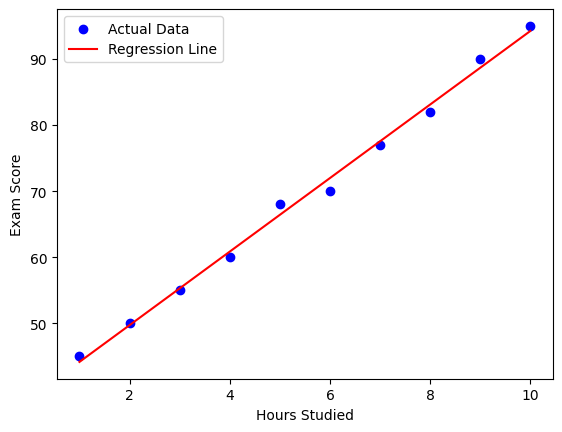

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Create dummy data (Hours Studied vs Exam Score)
# Reshaping is necessary because the model expects a 2D array for X
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y = np.array([45, 50, 55, 60, 68, 70, 77, 82, 90, 95])

# 2. Initialize and Train the Model
model = LinearRegression()
model.fit(X, y)

# 3. Make a prediction
hours = 8.5
prediction = model.predict([[hours]])

print(f"Predicted score for {hours} hours: {prediction[0]:.2f}")
print(f"Line Equation: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}")

# 4. Visualize the results
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.show()

MAE: 0.0820 | MSE: 0.0103 | RMSE: 0.1014
R2 Score: 1.0000 | Adjusted R2: 1.0000


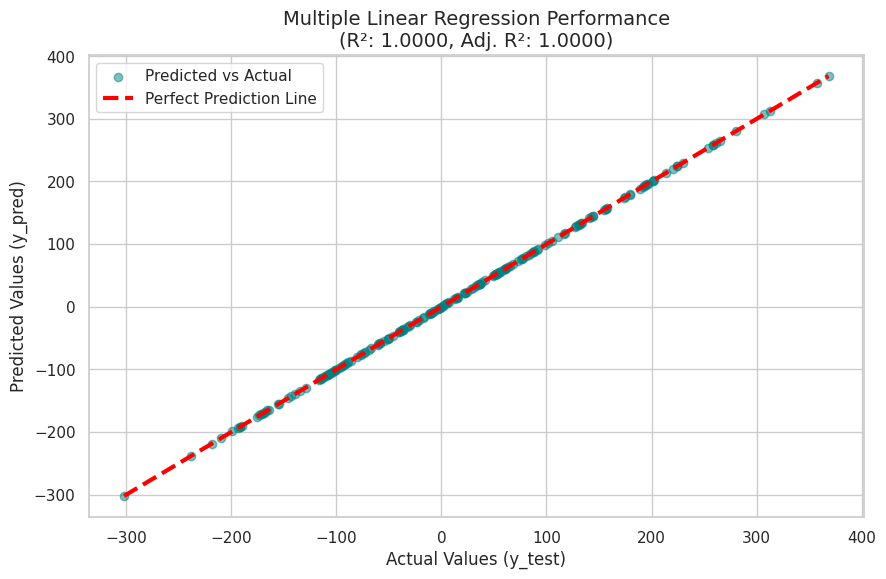

In [2]:
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import numpy as np

# 1. Create a dataset with 3 features
X, y = make_regression(n_samples=1000, n_features=3, noise=0.1, random_state=42)

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Model
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

# 4. Predictions
y_pred = mlr_model.predict(X_test)

# 5. Metrics Calculation
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

# Adjusted R-Squared calculation
n = X_test.shape[0] # Number of observations
p = X_test.shape[1] # Number of predictors
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f} | Adjusted R2: {adj_r2:.4f}")

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the style
sns.set_theme(style="whitegrid")

# 2. Create the Plot
plt.figure(figsize=(10, 6))

# Scatter plot of Actual vs Predicted
plt.scatter(y_test, y_pred, alpha=0.5, color='teal', label='Predicted vs Actual')

# Plot the "Perfect Fit" line (where Actual == Predicted)
line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=3, label='Perfect Prediction Line')

# 3. Add Labels and Title
plt.title(f'Multiple Linear Regression Performance\n(R²: {r2:.4f}, Adj. R²: {adj_r2:.4f})', fontsize=14)
plt.xlabel('Actual Values (y_test)', fontsize=12)
plt.ylabel('Predicted Values (y_pred)', fontsize=12)
plt.legend()

# Show the plot
plt.show()





      12-Hour 24-Hour
0  12:00 a.m.   00:00
1  12:15 a.m.   00:15
2  12:30 a.m.   00:30
3  12:45 a.m.   00:45
4   1:00 a.m.   01:00
Predicted Time: 23:58
Equation: y = 14.98x + 0.59


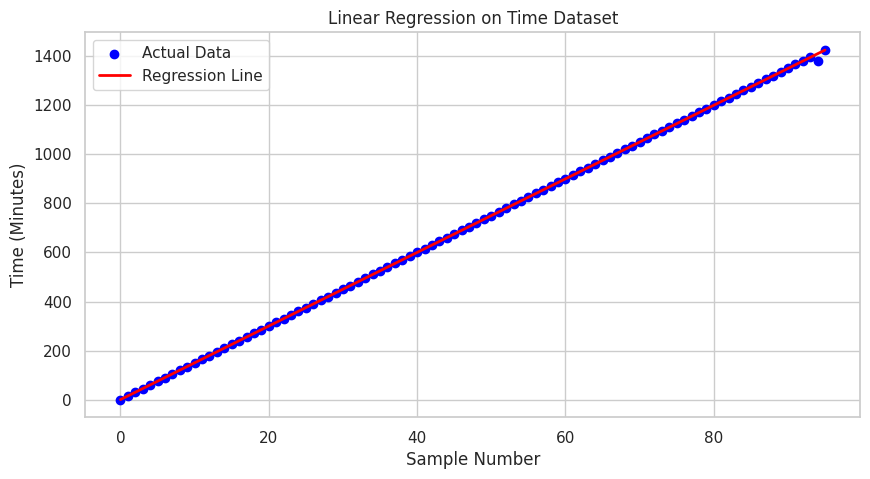

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Read the CSV file
df = pd.read_csv("/content/time.csv")

# Display first few rows
print(df.head())

# Convert 24-Hour time (HH:MM) to minutes
df["24-Hour"] = pd.to_datetime(df["24-Hour"], format="%H:%M")

df["Minutes"] = df["24-Hour"].dt.hour * 60 + df["24-Hour"].dt.minute

# Create X (input) and y (output)
X = np.arange(len(df)).reshape(-1, 1)
y = df["Minutes"]

# Train the model
model = LinearRegression()
model.fit(X, y)

# Predict the next value
next_index = [[len(df)]]
prediction = model.predict(next_index)

hours = int(prediction[0] // 60)
minutes = int(prediction[0] % 60)

print(f"Predicted Time: {hours:02d}:{minutes:02d}")
print(f"Equation: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}")

# Plot
plt.figure(figsize=(10,5))
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, model.predict(X), color="red", linewidth=2, label="Regression Line")

plt.xlabel("Sample Number")
plt.ylabel("Time (Minutes)")
plt.title("Linear Regression on Time Dataset")
plt.legend()
plt.grid(True)
plt.show()

   Experience (Years)  Salary ($)
0                 0.3       77484
1                 0.6      101084
2                 0.7       63327
3                 0.9       81343
4                 1.6       94752
Predicted Salary for 5 years of experience: $70,780.46
Equation: Salary = 181.38 * Experience + 69873.56


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


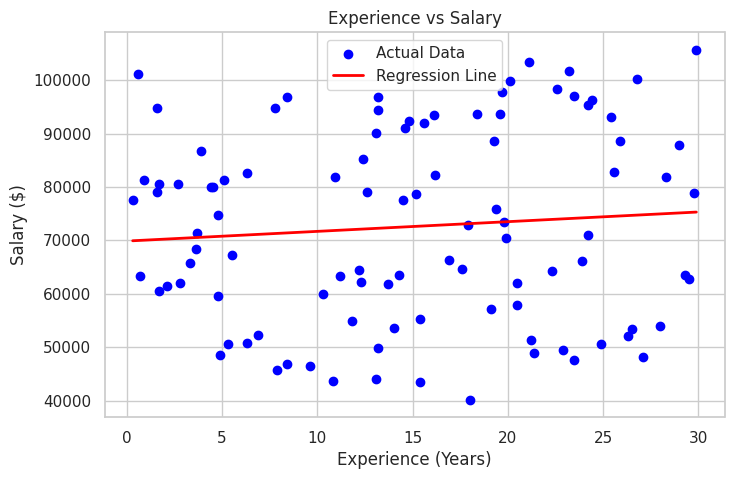

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Read dataset
df = pd.read_csv("/content/experience_vs_salary.csv")

# Display first 5 rows
print(df.head())

# Independent variable (Experience)
X = df[['Experience (Years)']]

# Dependent variable (Salary)
y = df['Salary ($)']

# Create and train model
model = LinearRegression()
model.fit(X, y)

# Predict salary for 5 years of experience
experience = 5
prediction = model.predict([[experience]])

print(f"Predicted Salary for {experience} years of experience: ${prediction[0]:,.2f}")

# Print equation
print(f"Equation: Salary = {model.coef_[0]:.2f} * Experience + {model.intercept_:.2f}")

# Plot
plt.figure(figsize=(8,5))f
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')

plt.xlabel("Experience (Years)")
plt.ylabel("Salary ($)")
plt.title("Experience vs Salary")
plt.legend()
plt.grid(True)

plt.show()

Intercept: -6661.987198813076
Coefficients: [6153.35330145 1836.01359426]

Regression Equation:
Salary = -6661.99 + (6153.35 × YearsExperience) + (1836.01 × Age)

Predicted Salary for 5 years experience and 30 years age = ₹79,185.19


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


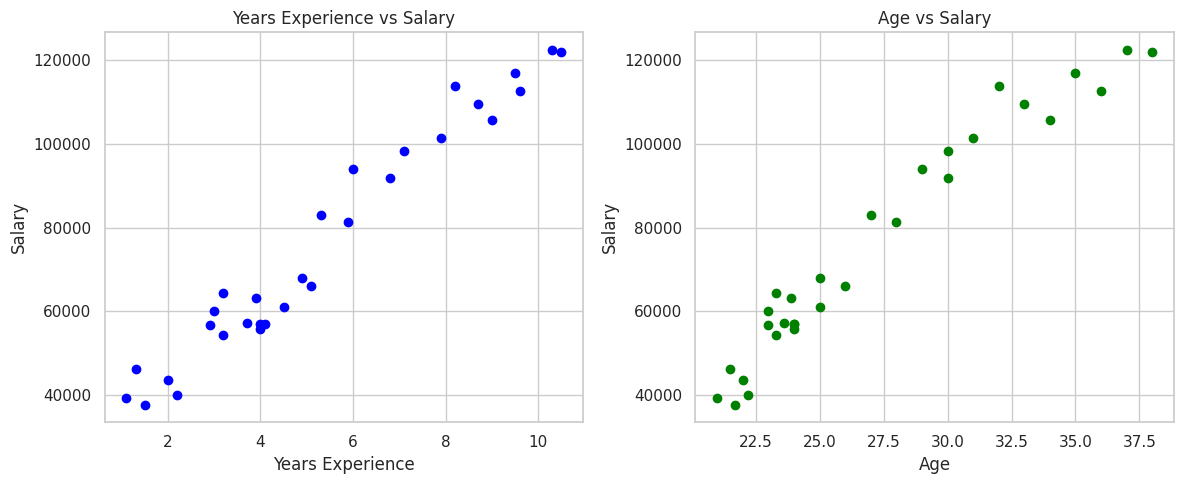

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


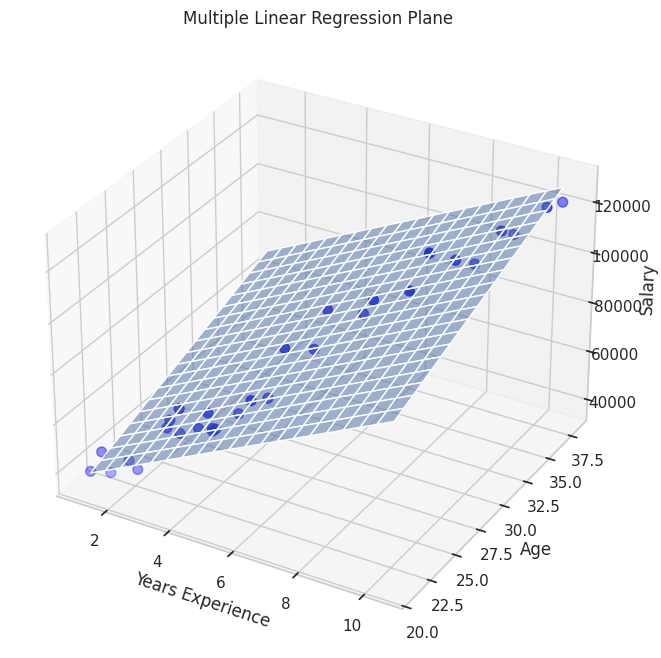

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("Salary_Data.csv")     # Change filename if needed

# Features (Independent Variables)
X = df[['YearsExperience', 'Age']]

# Target (Dependent Variable)
y = df['Salary']

# -----------------------------
# Train Model
# -----------------------------
model = LinearRegression()
model.fit(X, y)

# -----------------------------
# Model Parameters
# -----------------------------
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

print("\nRegression Equation:")
print(f"Salary = {model.intercept_:.2f} + "
      f"({model.coef_[0]:.2f} × YearsExperience) + "
      f"({model.coef_[1]:.2f} × Age)")

# -----------------------------
# Prediction
# -----------------------------
experience = 5
age = 30

prediction = model.predict([[experience, age]])

print(f"\nPredicted Salary for {experience} years experience and {age} years age = ₹{prediction[0]:,.2f}")

# -----------------------------
# Scatter Plots
# -----------------------------
plt.figure(figsize=(12,5))

# YearsExperience vs Salary
plt.subplot(1,2,1)
plt.scatter(df['YearsExperience'], y, color='blue')
plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.title("Years Experience vs Salary")

# Age vs Salary
plt.subplot(1,2,2)
plt.scatter(df['Age'], y, color='green')
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")

plt.tight_layout()
plt.show()

# -----------------------------
# 3D Regression Plane
# -----------------------------
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Scatter points
ax.scatter(df['YearsExperience'],
           df['Age'],
           y,
           color='blue',
           s=50,
           label='Actual Data')

# Create grid
x_range = np.linspace(df['YearsExperience'].min(),
                      df['YearsExperience'].max(),20)

age_range = np.linspace(df['Age'].min(),
                        df['Age'].max(),20)

X_grid, Age_grid = np.meshgrid(x_range, age_range)

# Predict plane
Salary_pred = model.predict(
    np.c_[X_grid.ravel(), Age_grid.ravel()]
).reshape(X_grid.shape)

# Plot regression plane
ax.plot_surface(X_grid,
                Age_grid,
                Salary_pred,
                alpha=0.5)

ax.set_xlabel("Years Experience")
ax.set_ylabel("Age")
ax.set_zlabel("Salary")

ax.set_title("Multiple Linear Regression Plane")

plt.show()